Task 1.1 — Speed check Make a list of 1,000,000 numbers. Compute the mean and max with
a plain Python loop, then again with NumPy. Confirm the answers match, and time both. How
much faster is NumPy, and why?

In [7]:
import numpy as np
import timeit

rng = np.random.default_rng(42)
numbers = rng.integers(0, 101, size=1_000_000)



def python_calculation():
    total = 0
    maximum = numbers[0]
    for number in numbers:
        total = total + number

        if number > maximum:
            maximum = number

    mean = total / len(numbers)

    return total, maximum, mean

def numpy_calculation():

    max_np = np.max(numbers)
    mean_np = np.mean(numbers)

    return max_np, mean_np

python_time = timeit.timeit(python_calculation, number=10)
np_time = timeit.timeit(numpy_calculation, number=10)

print(f"Python calculation time: {python_time:.6f} seconds")
print(f"Numpy calculation time: {np_time:.6f} seconds")


Python calculation time: 0.814116 seconds
Numpy calculation time: 0.018764 seconds


Task 1.2 — Array operations Build a 5×5 matrix of random numbers. Without loops, compute:
each row's sum, each column's mean, the overall max, and a boolean mask of all values above
the matrix average. Then replace every value below the average with 0 using that mask.


In [15]:
import numpy as np 

rng = np.random.default_rng(42)

matrix = rng.integers(0, 50, size=25).reshape(5, 5)

print("Matrix:")
print(matrix)

row_sums = matrix.sum(axis=1)    
column_means = matrix.mean(axis=0)   
overall_maximum = matrix.max()         
average = matrix.mean()                 
mask = matrix > average

matrix[matrix < average] = 0

print(f"Row sums: {row_sums}")
print(f"Column means: {column_means}")
print(f"Overall maximum: {overall_maximum}")
print(f"Average: {average}")

print(f"Mask:\n{mask}")
print(f"Modified matrix:\n{matrix}")

Matrix:
[[ 4 38 32 21 21]
 [42  4 34 10  4]
 [26 48 36 38 35]
 [39 25  6 41 22]
 [25 18  9 46 39]]
Row sums: [116  94 183 133 137]
Column means: [27.2 26.6 23.4 31.2 24.2]
Overall maximum: 48
Average: 26.52
Mask:
[[False  True  True False False]
 [ True False  True False False]
 [False  True  True  True  True]
 [ True False False  True False]
 [False False False  True  True]]
Modified matrix:
[[ 0 38 32  0  0]
 [42  0 34  0  0]
 [ 0 48 36 38 35]
 [39  0  0 41  0]
 [ 0  0  0 46 39]]


Task 1.3 — Broadcasting Make a 4×3 matrix. Subtract the column means from every row (so
each column becomes centered on 0) in a single line, using broadcasting. Confirm each
column's new mean is ~0


In [18]:
matrix = rng.integers(0, 50, size=(4, 3))

column_means = matrix.mean(axis=0)

centered = matrix - column_means

centered_mean = centered.mean(axis=0)

print("Original matrix:")
print(matrix)
print("Centered matrix:")
print(centered)
print("Mean of centered matrix (should be close to 0):")
print(centered_mean)

Original matrix:
[[38 37  9]
 [18 23 24]
 [ 2 27  7]
 [37 34 46]]
Centered matrix:
[[ 14.25   6.75 -12.5 ]
 [ -5.75  -7.25   2.5 ]
 [-21.75  -3.25 -14.5 ]
 [ 13.25   3.75  24.5 ]]
Mean of centered matrix (should be close to 0):
[0. 0. 0.]


Task 1.4 — Clean messy data Make an array with a few np.nan values and one obvious
outlier. Find them programmatically (not by eye), replace the NaNs with the median, and cap the
outlier. Report before/after mean.

In [28]:
data = np.array([10, 12, 15, np.nan, 14, 13, np.nan, 500])
print("Data with outliers and NaN values:", data)

nan_mask = np.isnan(data)

median = np.nanmedian(data)
print(f"Median (ignoring NaN values): {median}")

modified_data = data.copy()
modified_data[nan_mask] = median

outlier_mask = data > (3 * median)

modified_data[outlier_mask] = 3 * median

print(data[outlier_mask])

print("Modified data (NaN values replaced with median):", modified_data)


Data with outliers and NaN values: [ 10.  12.  15.  nan  14.  13.  nan 500.]
Median (ignoring NaN values): 13.5
[500.]
Modified data (NaN values replaced with median): [10.  12.  15.  13.5 14.  13.  13.5 40.5]


Block 2 — Linear Algebra

Task 2.1 — Vectors Take two vectors. Compute their dot product, both their lengths (norms),
and the angle between them — from scratch (dot product and norms with NumPy, then the
angle formula). Verify the angle against np.arccos

In [34]:
import numpy as np

a = np.array([3, 4])
b = np.array([4, 3])
dot_product = np.dot(a, b)

norm_a = np.linalg.norm(a)
norm_b = np.linalg.norm(b)

cos_theta = (a @ b) / (np.linalg.norm(a) * np.linalg.norm(b))
theta = np.arccos(cos_theta)
angle_degrees = np.degrees(theta)

print(f"Dot product of a and b: {dot_product}")
print(f"Norm of a: {norm_a}")
print(f"Norm of b: {norm_b}")
print(f"Angle between a and b: {theta} radians")
print(f"Angle between a and b: {angle_degrees} degrees")

Dot product of a and b: 24
Norm of a: 5.0
Norm of b: 5.0
Angle between a and b: 0.283794109208328 radians
Angle between a and b: 16.260204708311967 degrees


Task 2.2 — Matrix as transformation Apply the matrix [[2,0],[0,0.5]] to a set of points
forming a square. Plot before and after. Describe in words what the transformation did. Then
compute the determinant and explain what its value means about area.

[[0.  0. ]
 [2.  0. ]
 [2.  0.5]
 [0.  0.5]]
Determinant of A: 1.0


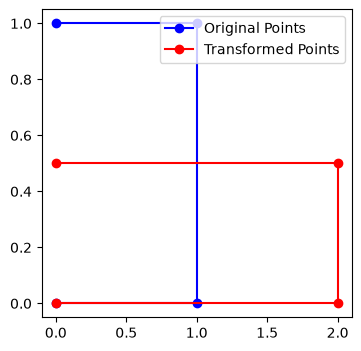

In [ ]:
import matplotlib.pyplot as plt

A = np.array([
    [2, 0],
    [0, 0.5]
])

points = np.array([
    [0, 0],
    [1, 0],
    [1, 1],
    [0, 1]
])

maltiplied_points = points @ A.T


det = np.linalg.det(A)

print(maltiplied_points)
print(f"Determinant of A: {det}")



Task 2.3 — Eigenvectors from scratch For [[2,1],[1,2]], find the eigenvalues by solving
det(A − λI) = 0 by hand, then verify with np.linalg.eig. Plot one eigenvector before
and after the transformation to show it stays on its own line.

Eigenvalues: [3. 1.]
Eigenvectors:
 [[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]
Original vector: [1 1]
Transformed vector: [3 3]


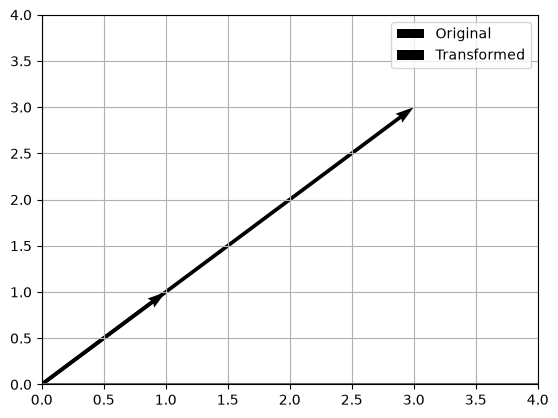

In [45]:
import numpy as np
import matplotlib.pyplot as plt

A = np.array([
    [2, 1],
    [1, 2]
])

eigenvalues, eigenvectors = np.linalg.eig(A)

print("Eigenvalues:", eigenvalues)
print("Eigenvectors:\n", eigenvectors)

v = np.array([1, 1])
transformed_v = A @ v

print("Original vector:", v)
print("Transformed vector:", transformed_v)

plt.quiver(
    0, 0, v[0], v[1],
    angles="xy", scale_units="xy", scale=1,
    label="Original"
)

plt.quiver(
    0, 0, transformed_v[0], transformed_v[1],
    angles="xy", scale_units="xy", scale=1,
    label="Transformed"
)

plt.xlim(0, 4)
plt.ylim(0, 4)
plt.axhline(0)
plt.axvline(0)
plt.grid()
plt.legend()
plt.show()

Task 2.4 — PCA / SVD Take a small dataset (or reuse the student data). Standardize it,
compute the covariance matrix, and find its eigenvalues. Report how much variance the top
component explains. Bonus: verify with SVD.

In [51]:
X = np.array([
    [10, 20],
    [20, 30],
    [30, 40],
    [40, 50]
], dtype=float)

mean = X.mean(axis=0)
std = X.std(axis=0)

z = (X - mean) / std

cov = np.cov(z, rowvar=False)

eigenvalues, eigenvectors = np.linalg.eig(cov)

total_variance = eigenvalues.sum()
top_variance = eigenvalues.max()
explained = top_variance / total_variance




print (z)
print("Covariance matrix:\n", cov)
print("Eigenvalues:", eigenvalues)
print("Eigenvectors:\n", eigenvectors)
print(f"Explained variance ratio: {explained:.4f}")

[[-1.34164079 -1.34164079]
 [-0.4472136  -0.4472136 ]
 [ 0.4472136   0.4472136 ]
 [ 1.34164079  1.34164079]]
Covariance matrix:
 [[1.33333333 1.33333333]
 [1.33333333 1.33333333]]
Eigenvalues: [2.66666667 0.        ]
Eigenvectors:
 [[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]
Explained variance ratio: 1.0000


Block 3 — Calculus + Gradient Descent

Task 3.1 — Derivative by hand and numerically Pick a function like f(x) = x² + 3x. Compute its derivative by hand, then approximate it numerically (nudge x by a tiny amount). Confirm they match at several points.

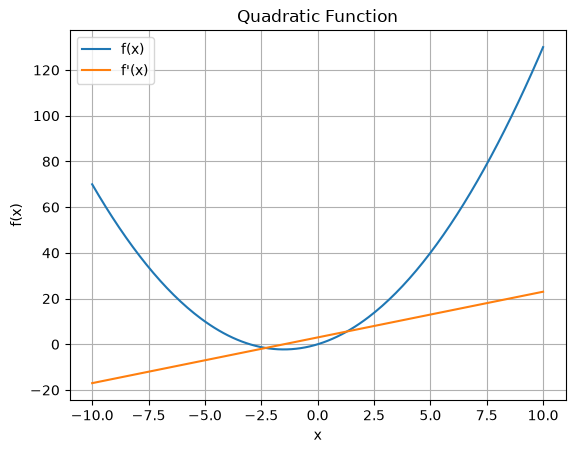

In [54]:
import numpy as np 
import matplotlib.pyplot as plt

x = np.linspace(-10,10, 200)

f = lambda x: x**2 + 3*x
y = f(x)

df = lambda x: 2*x + 3
dy = df(x)

plt.plot(x, y, label='f(x)')
plt.plot(x, dy, label="f'(x)")
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Quadratic Function')
plt.grid(True)
plt.legend()
plt.show()

Task 3.2 — Gradient descent from scratch Write a gradient_descent(grad_fn, start, lr, steps) function. Use it to minimize (x−5)² starting from 0. Plot the path of steps rolling into the minimum. Confirm it reaches 5.

In [57]:
f = lambda x: (x - 5)**2
df = lambda x: 2*(x - 5)

def gradient_descent(grad_fn, start, lr, steps):
    x = start

    for i in range(steps):
        x = x - lr * grad_fn(x)

    return x
result = gradient_descent(df, 0, 0.1, 10)

print(result)

4.4631290880000005


Task 3.3 — The learning rate Run your gradient descent on the same function with learning rates 0.01, 0.1, 0.9, and 1.05. Report which converge, which crawls, and which diverges. Find the exact learning rate above which it blows up.

In [58]:
lrs = [0.01, 0.1, 0.9, 1.05]

for lr in lrs:
    result = gradient_descent(df, 0, lr, 100)
    print(lr, result)

0.01 4.336902220526234
0.1 4.999999998981481
0.9 4.999999998981481
1.05 -68898.06169911195


Task 3.4 — Backprop by hand For a tiny network a = w·x, loss = (a − target)², do a forward pass and a backward pass by hand to get d(loss)/dw. Verify numerically. Take one update step and confirm the loss drops.

In [59]:
x = 2
w = 3
target = 10

a = w * x
loss = (a - target)**2

d_loss_dw = 2 * (a - target) * x

learning_rate = 0.1
w_new = w - learning_rate * d_loss_dw

a_new = w_new * x
loss_new = (a_new - target)**2

print("Old loss:", loss)
print("New loss:", loss_new)


Old loss: 16
New loss: 0.6400000000000011


Block 4 — Probability + Distributions

Task 4.1 — Bayes' theorem A disease affects 1% of people. A test is 99% accurate on the sick and 95% accurate on the healthy. Compute P(disease | positive test) with Bayes. Then verify it with a Monte Carlo simulation of a million people. Explain in plain English why the answer is so surprisingly low.

In [60]:
import numpy as np

rng = np.random.default_rng(42)

# 1,000,000 people
n = 1_000_000

# 1% have the disease
disease = rng.random(n) < 0.01

# Generate one random number for each person's test
test_random = rng.random(n)

# Positive test:
# sick -> 99% chance positive
# healthy -> 5% chance positive
positive = np.where(
    disease,
    test_random < 0.99,
    test_random < 0.05
)

# Count positive tests
total_positive = positive.sum()

# Count people who are both sick AND positive
sick_positive = (disease & positive).sum()

# P(disease | positive)
probability = sick_positive / total_positive

print("Total people:", n)
print("People with disease:", disease.sum())
print("Positive tests:", total_positive)
print("Sick + positive:", sick_positive)
print("P(disease | positive):", probability)
print("Percentage:", probability * 100)

Total people: 1000000
People with disease: 10064
Positive tests: 59283
Sick + positive: 9951
P(disease | positive): 0.1678558777389808
Percentage: 16.78558777389808


Task 4.2 — Expectation and variance For a fair die, compute E[X] and Var[X] from the definition. Then estimate both from a large simulated sample and confirm they converge

In [61]:
outcomes = np.array([1, 2, 3, 4, 5, 6])
probability = np.ones(6) / 6

# Expected value
expected = np.sum(outcomes * probability)

# Variance
variance = np.sum((outcomes - expected)**2 * probability)

print("Expected value:", expected)
print("Variance:", variance)

Expected value: 3.5
Variance: 2.9166666666666665


Task 4.3 — The five distributions Sample from uniform, normal, binomial, Poisson, and exponential. Plot all five histograms. For each, confirm the sample mean/variance matches theory. Confirm the Poisson's mean ≈ variance.

In [63]:
rng = np.random.default_rng(42)

n = 100_000

# 1. Uniform: 0 to 10
uniform = rng.uniform(0, 10, n)

# 2. Normal: mean = 0, std = 1
normal = rng.normal(0, 1, n)

# 3. Binomial: n = 10, p = 0.5
binomial = rng.binomial(10, 0.5, n)

# 4. Poisson: lambda = 4
poisson = rng.poisson(4, n)

# 5. Exponential: scale = 2
exponential = rng.exponential(2, n)

print("Uniform distribution: mean =", uniform.mean(), ", std =", uniform.std())
print("Normal distribution: mean =", normal.mean(), ", std =", normal.std())
print("Binomial distribution: mean =", binomial.mean(), ", std =", binomial.std())
print("Poisson distribution: mean =", poisson.mean(), ", std =", poisson.std())

Uniform distribution: mean = 5.006249366621587 , std = 2.8851945051403747
Normal distribution: mean = 0.0027505170737213303 , std = 1.001693228323139
Binomial distribution: mean = 5.00215 , std = 1.5760156653726511
Poisson distribution: mean = 3.99863 , std = 1.995461882146587


Task 4.4 — Central Limit Theorem Start with a flat uniform distribution. Repeatedly average n samples (for n = 1, 2, 5, 30) and plot the distribution of those averages. Watch a bell curve emerge from the flat one. Confirm the spread shrinks by √n.

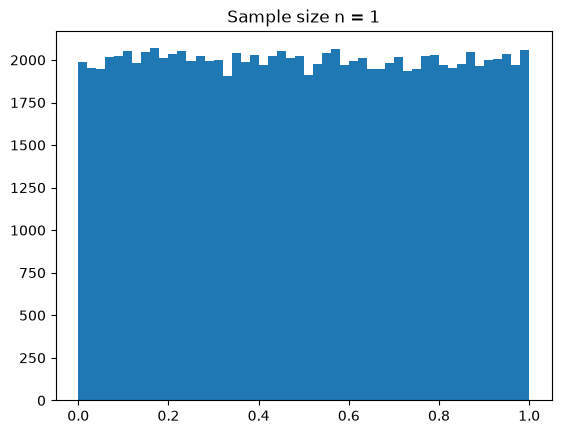

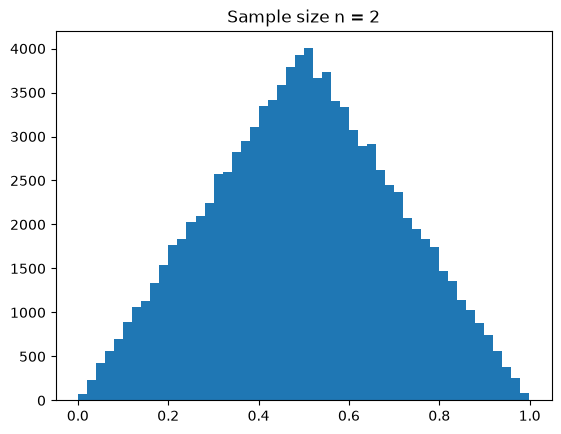

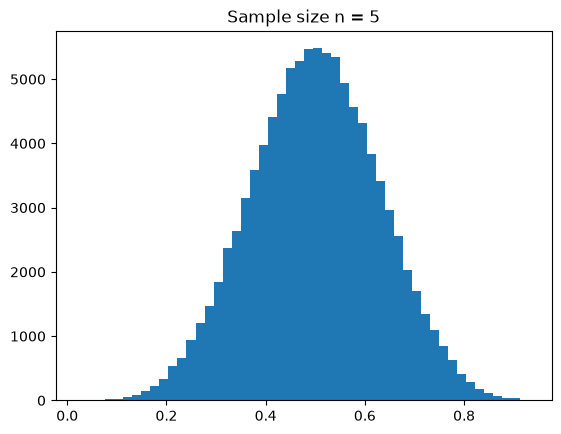

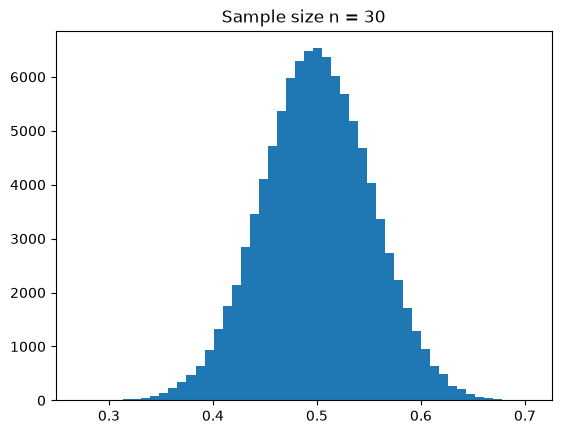

n = 1 actual std = 0.2884058867525713 expected std = 0.2885194505140375
n = 2 actual std = 0.20414868347902948 expected std = 0.20401405996269242
n = 5 actual std = 0.12929825446492368 expected std = 0.12902982083605488
n = 30 actual std = 0.05270775799657602 expected std = 0.05267620377517794


In [64]:
rng = np.random.default_rng(42)

n_samples = 100_000

data = rng.uniform(0, 1, n_samples)


sample_sizes = [1, 2, 5, 30]

for n in sample_sizes:
    samples = rng.uniform(0, 1, (n_samples, n))
    averages = samples.mean(axis=1)

    plt.hist(averages, bins=50)
    plt.title(f"Sample size n = {n}")
    plt.show()

original_std = data.std()

for n in sample_sizes:
    samples = rng.uniform(0, 1, (n_samples, n))
    averages = samples.mean(axis=1)

    print(
        "n =", n,
        "actual std =", averages.std(),
        "expected std =", original_std / np.sqrt(n)
    )

Task 4.5 — Distribution fitting Take a dataset, fit two candidate distributions with scipy.stats, and compare them by log-likelihood. Which fits best, and what does that tell you about the data?

In [68]:
from scipy import stats
normal_params = stats.norm.fit(data)

# Fit exponential distribution
exponential_params = stats.expon.fit(data)

print("Normal parameters:", normal_params)
print("Exponential parameters:", exponential_params)


normal_loglik = np.sum(
    stats.norm.logpdf(data, *normal_params)
)

exponential_loglik = np.sum(
    stats.expon.logpdf(data, *exponential_params)
)

print("Normal log-likelihood:", normal_loglik)
print("Exponential log-likelihood:", exponential_loglik)

if exponential_loglik > normal_loglik:
    print("Exponential distribution fits better")
else:
    print("Normal distribution fits better")

Normal parameters: (np.float64(0.5006249366621587), np.float64(0.2885194505140375))
Exponential parameters: (1.3168556207476811e-05, 0.5006117681059512)
Normal log-likelihood: -17594.575735750215
Exponential log-likelihood: -30807.560774152775
Normal distribution fits better


Tie it together: Take one dataset. Clean it (Block 1), find its structure with PCA (Block 2), predict a column with your own gradient descent (Block 3), and fit a distribution + run one Bayes or hypothesis question on it (Block 4). One dataset, all four skills — this is what real data work looks like.

block 01


In [72]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(42)

hours = rng.uniform(1, 10, 500)
sleep = rng.normal(7, 1, 500)
score = 40 + 5 * hours + 2 * sleep + rng.normal(0, 5, 500)

hours[10] = np.nan
sleep[20] = np.nan
score[30] = np.nan

print(np.isnan(hours).sum())
print(np.isnan(sleep).sum())
print(np.isnan(score).sum())

hours[np.isnan(hours)] = np.nanmedian(hours)
sleep[np.isnan(sleep)] = np.nanmedian(sleep)
score[np.isnan(score)] = np.nanmedian(score)

print(np.isnan(hours).sum())
print(np.isnan(sleep).sum())
print(np.isnan(score).sum())

1
1
1
0
0
0


(500, 3)
X_scaled [[ 0.97061449  1.47106764  0.56363257]
 [-0.19922202  0.15180166 -0.08322916]
 [ 1.26611961  0.63287994  1.53350336]
 [ 0.70322729  0.00597739  0.78734438]
 [-1.40265642 -0.1057476  -1.09550303]]
cov_matrix [[ 1.00200401 -0.02686251  0.92095839]
 [-0.02686251  1.00200401  0.11318011]
 [ 0.92095839  0.11318011  1.00200401]]
Eigenvalues: [1.92701304 1.00850312 0.07049586]
Eigenvectors:
[[ 0.70303847 -0.12173288  0.70065542]
 [ 0.066219    0.99216561  0.10593606]
 [ 0.70806211  0.02808042 -0.70559162]]
Index: [1 2 0]
X_pca shape: (500, 2)
Explained variance: [0.64105301 0.33549537 0.02345162]
First 2 components: 0.9765483769543193


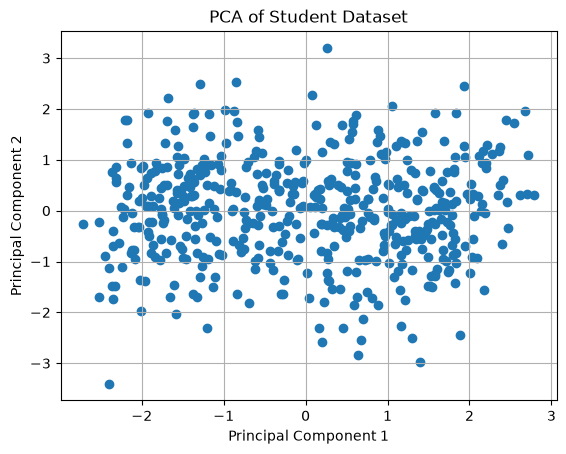

In [78]:
X = np.column_stack([hours, sleep, score])

print(X.shape)

mean = X.mean(axis=0)
std = X.std(axis=0)

X_scaled = (X - mean) / std

cov_matrix = np.cov(X_scaled, rowvar=False)

eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

idx = np.argsort(eigenvalues)[::-1]

eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

components = eigenvectors[:, :2]

X_pca = X_scaled @ components

explained_variance = eigenvalues / eigenvalues.sum()


print("X_scaled" , X_scaled[:5])
print("cov_matrix", cov_matrix)


print("Eigenvalues:", eigenvalues)

print("Eigenvectors:")
print(eigenvectors)

print("Index:", idx)

print("X_pca shape:", X_pca.shape)

print("Explained variance:", explained_variance)
print("First 2 components:", explained_variance[:2].sum())

plt.scatter(X_pca[:, 0], X_pca[:, 1])
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA of Student Dataset")
plt.grid(True)
plt.show()

Block -03

X_scaled shape: (500, 3)
Final weights: [81.23294186 12.78354408  1.90744569]
Weights: [81.23294186 12.78354408  1.90744569]
MSE: 26.152268477114994


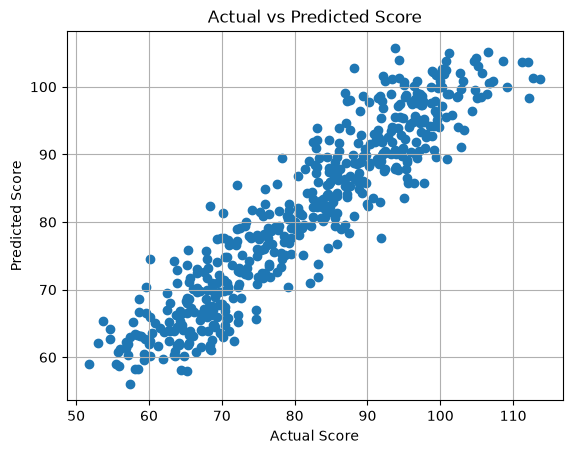

In [79]:
X = np.column_stack([hours, sleep])
y = score

X_mean = X.mean(axis=0)
X_std = X.std(axis=0)

X_scaled = (X - X_mean) / X_std

X_scaled = np.column_stack([
    np.ones(len(X_scaled)),
    X_scaled
])

weights = np.zeros(X_scaled.shape[1])


learning_rate = 0.01
steps = 1000

for i in range(steps):

    predictions = X_scaled @ weights

    error = predictions - y

    gradient = (2 / len(X_scaled)) * (X_scaled.T @ error)

    weights = weights - learning_rate * gradient

predictions = X_scaled @ weights

mse = np.mean((predictions - y) ** 2)


print("X_scaled shape:", X_scaled.shape)

print("Final weights:", weights)

print("Weights:", weights)

print("MSE:", mse)

plt.scatter(y, predictions)

plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.title("Actual vs Predicted Score")
plt.grid(True)
plt.show()

Block - 04

In [82]:
from scipy import stats

P_disease = 0.01

P_positive_given_disease = 0.99
P_positive_given_healthy = 0.05

P_healthy = 1 - P_disease

P_positive = (
    P_positive_given_disease * P_disease
    + P_positive_given_healthy * P_healthy
)

P_disease_given_positive = (
    P_positive_given_disease * P_disease
    / P_positive
)



print("P(disease | positive):", P_disease_given_positive)
print("Percentage:", P_disease_given_positive * 100)

P(disease | positive): 0.16666666666666669
Percentage: 16.666666666666668


In [81]:
rng = np.random.default_rng(42)

n = 1_000_000

disease = rng.random(n) < 0.01

test_random = rng.random(n)

positive = np.where(
    disease,
    test_random < 0.99,
    test_random < 0.05
)

sick_positive = (disease & positive).sum()

simulated_probability = sick_positive / positive.sum()

print("Simulated probability:", simulated_probability)
print("Simulated percentage:", simulated_probability * 100)

Simulated probability: 0.1678558777389808
Simulated percentage: 16.78558777389808
